# Data Mining
# Week 5
# Submitter - Himanshu Singh
# Classification Models and Clustering

You will build a model with the movie reviews dataset that you worked with in Week 3: Bag of Words Meets Bags of Popcorn. 



* Get the stemmed data using the same process you did in Week 3.


In [93]:
import pandas as pd
from nltk.stem import PorterStemmer
import re

# Load data 
df = pd.read_csv('labeledTrainData.tsv', sep='\t', quoting=3)

def stem_text(text):
    # Clean and stem 
    text = re.sub(r'<[^>]*>', ' ', text)
    words = re.sub(r'[^a-zA-Z]', ' ', text).lower().split()
    ps = PorterStemmer()
    return ' '.join([ps.stem(w) for w in words])

df['stemmed_review'] = df['review'].apply(stem_text)
df.head()

,id,sentiment,review,stemmed_review
0,"""5814_8""",1,"""With all this stuff going down at the moment ...",with all thi stuff go down at the moment with ...
1,"""2381_9""",1,"""\""The Classic War of the Worlds\"" by Timothy ...",the classic war of the world by timothi hine i...
2,"""7759_3""",0,"""The film starts with a manager (Nicholas Bell...",the film start with a manag nichola bell give ...
3,"""3630_4""",0,"""It must be assumed that those who praised thi...",it must be assum that those who prais thi film...
4,"""9495_8""",1,"""Superbly trashy and wondrously unpretentious ...",superbl trashi and wondrous unpretenti s explo...


* Split this into a training and test set.


In [94]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['stemmed_review'], df['sentiment'], test_size=0.2, random_state=42
)

* Fit and apply the tf-idf vectorization to the training set.
* Apply but DO NOT FIT the tf-idf vectorization to the test set (Why?).


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# We DO NOT FIT the tf-idf vectorization to the test set in order to avoid data leakage. If we fit on the test set, 
# the model "peeks" at the word frequencies of the data it's supposed to be tested on, leading to over-optimistic 
# performance results.


* Train a logistic regression using the training data.
* Find the model accuracy on test set.
* Create a confusion matrix for the test set predictions.
* Get the precision, recall, and F1-score for the test set predictions.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# Train model
# added the solver and max_iter to ensure convergence and avoid warnings
lr_model = LogisticRegression(solver='liblinear', max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# Predict and Evaluate
y_pred = lr_model.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8858
[[2165  316]
 [ 255 2264]]
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      2481
           1       0.88      0.90      0.89      2519

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



* Create a ROC curve for the test set.

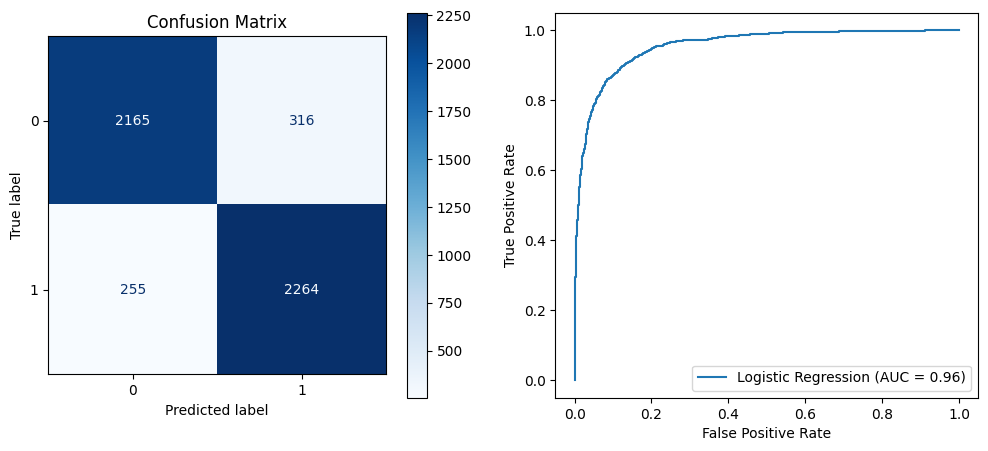

In [ ]:
import matplotlib.pyplot as plt

#  Visualizations
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues')
ax[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, lr_model.predict_proba(X_test_tfidf)[:,1])
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc(fpr, tpr):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

* Pick another classification model you learned about this week and repeat steps (5) – (9).

Accuracy: 0.8424
[[2089  392]
 [ 396 2123]]
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      2481
           1       0.84      0.84      0.84      2519

    accuracy                           0.84      5000
   macro avg       0.84      0.84      0.84      5000
weighted avg       0.84      0.84      0.84      5000



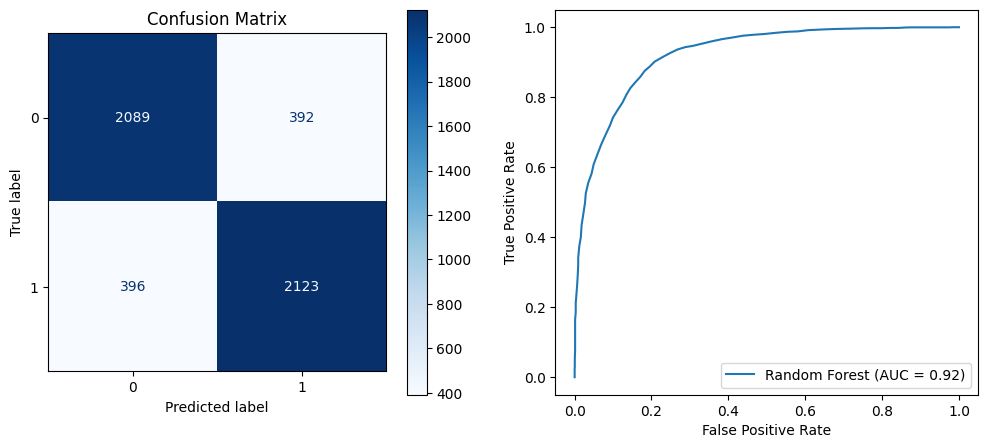

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.ensemble import RandomForestClassifier


# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

# 2. Print Basic Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# 3. Visualizations
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# # Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[0], cmap='Blues')
ax[0].set_title("Confusion Matrix")


fpr, tpr, _ = roc_curve(y_test, rf_model.predict_proba(X_test_tfidf)[:,1])
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc(fpr, tpr):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_probs, ax=ax[1])
ax[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()
